In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from numpy import linspace
from scipy.stats import gaussian_kde

import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("future.no_silent_downcasting", True)

In [3]:
oscars_summary = pd.read_csv("oscars_summary.csv")
acting_summary = pd.read_csv("acting_summary.csv")
gender_age = pd.read_csv("gender_age.csv")
gender_rt = pd.read_csv("gender_rt.csv")

# Linear Regression Analysis

In [3]:
m_ols1 = smf.ols("total_nominations ~ pct_words_m + pct_chars_m + avg_male_words", data=oscars_summary).fit()
print(m_ols1.summary())

                            OLS Regression Results                            
Dep. Variable:      total_nominations   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     15.89
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           3.28e-10
Time:                        16:48:10   Log-Likelihood:                -4008.4
No. Observations:                1947   AIC:                             8025.
Df Residuals:                    1943   BIC:                             8047.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.4868      0.214     -2.

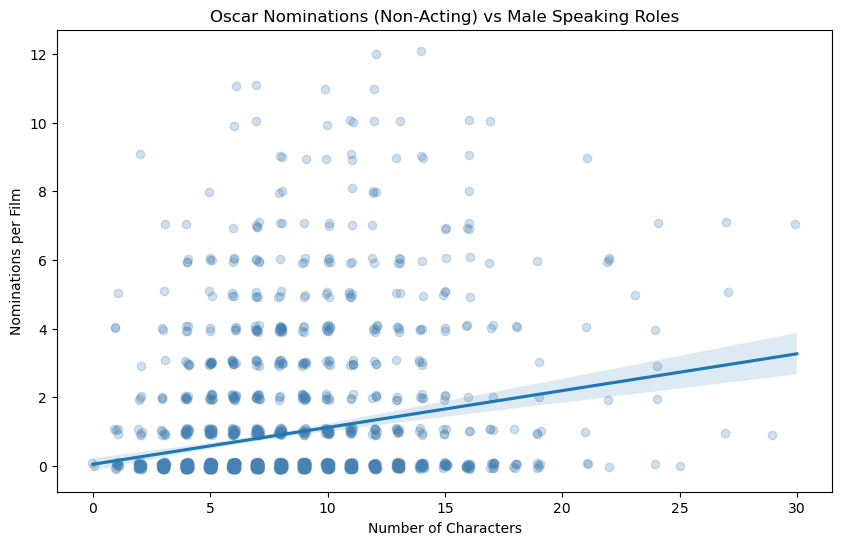

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=oscars_summary,
    x="num_characters_m",
    y="total_nominations",
    x_jitter=0.1,
    y_jitter=0.1,
    scatter_kws={"alpha": 0.25, "color": "steelblue"}
)

plt.title("Oscar Nominations (Non-Acting) vs Male Speaking Roles")
plt.xlabel("Number of Characters")
plt.ylabel("Nominations per Film")
plt.show()

                            OLS Regression Results                            
Dep. Variable:      total_nominations   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     96.52
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           2.88e-22
Time:                        16:04:20   Log-Likelihood:                -3984.9
No. Observations:                1947   AIC:                             7974.
Df Residuals:                    1945   BIC:                             7985.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0440      0.098  

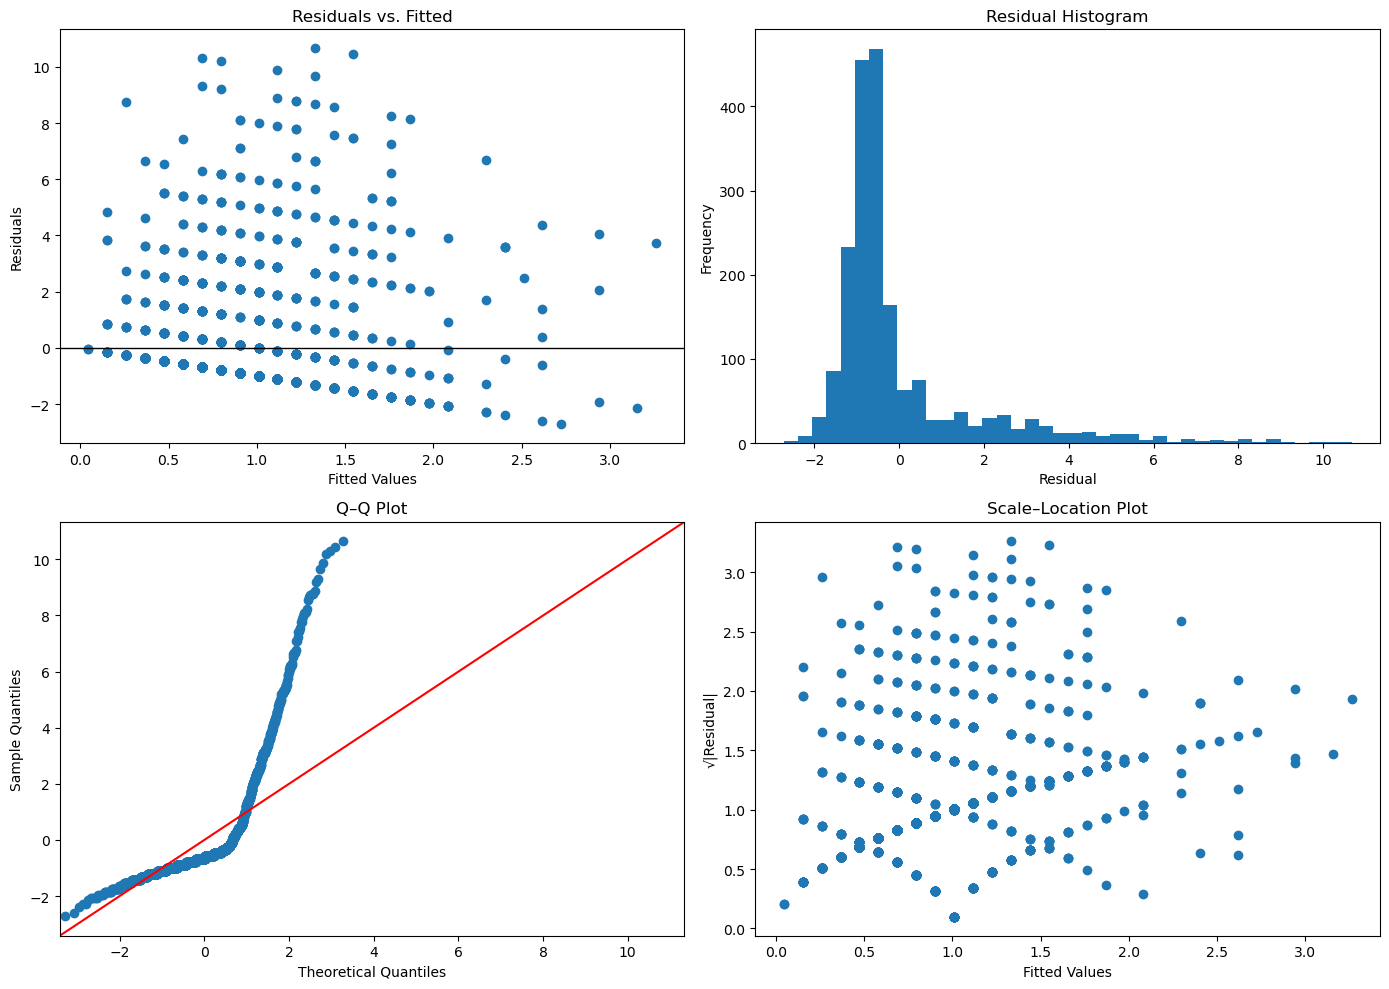

In [ ]:
ols2_X = sm.add_constant(oscars_summary["num_characters_m"])
ols2_y = oscars_summary["total_nominations"]

m_ols2 = sm.OLS(ols2_y, ols2_X).fit()
print(m_ols2.summary())

residuals = m_ols2.resid
fitted = m_ols2.fittedvalues

# Create diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted, residuals)
axes[0, 0].axhline(0, color="black", linewidth=1)
axes[0, 0].set_title("Residuals vs. Fitted")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")

# 2. Histogram of residuals
axes[0, 1].hist(residuals, bins=40)
axes[0, 1].set_title("Residual Histogram")
axes[0, 1].set_xlabel("Residual")
axes[0, 1].set_ylabel("Frequency")

# 3. Q-Q plot
sm.qqplot(residuals, line="45", ax=axes[1, 0])
axes[1, 0].set_title("Q–Q Plot")

# 4. Scale–Location plot (sqrt(|residual|) vs fitted)
axes[1, 1].scatter(fitted, np.sqrt(np.abs(residuals)))
axes[1, 1].set_title("Scale–Location Plot")
axes[1, 1].set_xlabel("Fitted Values")
axes[1, 1].set_ylabel("√|Residual|")

plt.tight_layout()
plt.show()

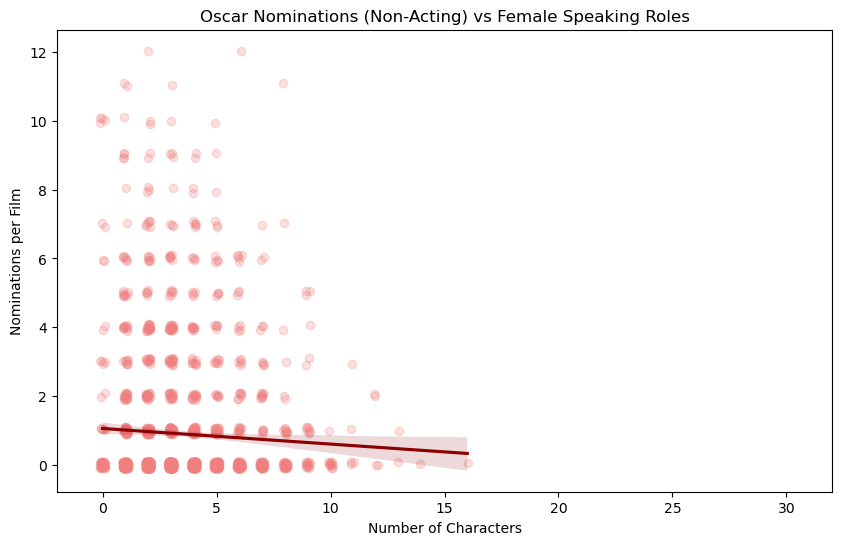

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=oscars_summary,
    x="num_characters_f",
    y="total_nominations",
    x_jitter=0.1,
    y_jitter=0.1,
    scatter_kws={"alpha": 0.25, "color": "lightcoral"},
    line_kws={"color": "darkred"}
)

plt.xlim(-2, 32)
plt.title("Oscar Nominations (Non-Acting) vs Female Speaking Roles")
plt.xlabel("Number of Characters")
plt.ylabel("Nominations per Film")
plt.show()

                            OLS Regression Results                            
Dep. Variable:      total_nominations   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     4.941
Date:                Mon, 17 Nov 2025   Prob (F-statistic):             0.0263
Time:                        16:05:11   Log-Likelihood:                -4029.6
No. Observations:                1947   AIC:                             8063.
Df Residuals:                    1945   BIC:                             8074.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.0632      0.083  

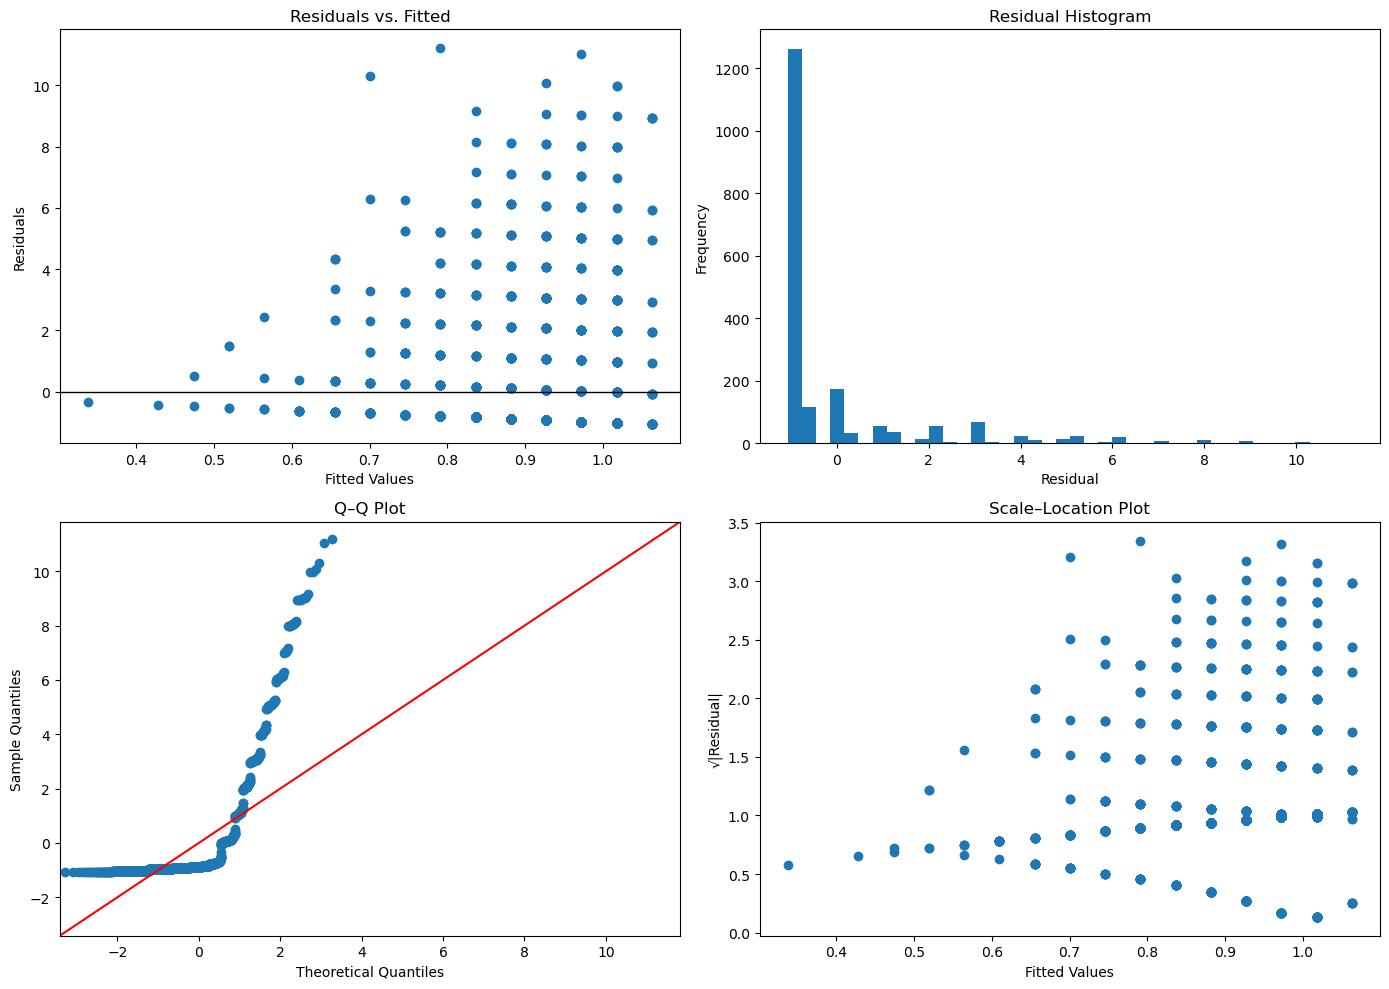

In [ ]:
fols_X = sm.add_constant(oscars_summary["num_characters_f"])
fols_y = oscars_summary["total_nominations"]

f_ols1 = sm.OLS(fols_y, fols_X).fit()
print(f_ols1.summary())

residuals = f_ols1.resid
fitted = f_ols1.fittedvalues

# Create diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted, residuals)
axes[0, 0].axhline(0, color="black", linewidth=1)
axes[0, 0].set_title("Residuals vs. Fitted")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")

# 2. Histogram of residuals
axes[0, 1].hist(residuals, bins=40)
axes[0, 1].set_title("Residual Histogram")
axes[0, 1].set_xlabel("Residual")
axes[0, 1].set_ylabel("Frequency")

# 3. Q-Q plot
sm.qqplot(residuals, line="45", ax=axes[1, 0])
axes[1, 0].set_title("Q–Q Plot")

# 4. Scale–Location plot (sqrt(|residual|) vs fitted)
axes[1, 1].scatter(fitted, np.sqrt(np.abs(residuals)))
axes[1, 1].set_title("Scale–Location Plot")
axes[1, 1].set_xlabel("Fitted Values")
axes[1, 1].set_ylabel("√|Residual|")

plt.tight_layout()
plt.show()

In [ ]:
print((oscars_summary["total_nominations"] == 0).mean())
oscars_summary["total_nominations"].var(), oscars_summary["total_nominations"].mean()

0.7077555213148433


(3.685597944712597, 0.9070364663585002)

# Negative Binomial Regression Analysis

In [ ]:
nb1_y = oscars_summary["total_nominations"]
nb1_X = sm.add_constant(oscars_summary[["num_characters_m", "num_characters_f"]])

model_nb1 = sm.NegativeBinomial(nb1_y, nb1_X).fit()
print(model_nb1.summary())

# # 1. Residuals vs Fitted (Pearson)
# axes[0, 0].scatter(fitted, resid_pearson, alpha=0.5)
# axes[0, 0].axhline(0, color='black', linewidth=1)
# axes[0, 0].set_title("Pearson Residuals vs Fitted")
# axes[0, 0].set_xlabel("Fitted Values")
# axes[0, 0].set_ylabel("Pearson Residuals")

# # 2. Histogram of Pearson residuals
# axes[0, 1].hist(resid_pearson, bins=40, alpha=0.7)
# axes[0, 1].set_title("Histogram of Pearson Residuals")
# axes[0, 1].set_xlabel("Residual")
# axes[0, 1].set_ylabel("Frequency")

# # 3. Q-Q plot of Pearson residuals
# sm.qqplot(resid_pearson, line='45', ax=axes[1, 0])
# axes[1, 0].set_title("Q-Q Plot of Deviance Residuals")

# # 4. Predicted vs Observed
# axes[1, 1].scatter(fitted, y, alpha=0.5)
# axes[1, 1].plot([0, max(y)], [0, max(y)], color='red', linestyle='--')
# axes[1, 1].set_title("Predicted vs Observed Total Nominations")
# axes[1, 1].set_xlabel("Predicted")
# axes[1, 1].set_ylabel("Observed")

# plt.tight_layout()
# plt.show()

Optimization terminated successfully.
         Current function value: 1.164782
         Iterations: 12
         Function evaluations: 17
         Gradient evaluations: 17
                     NegativeBinomial Regression Results                      
Dep. Variable:      total_nominations   No. Observations:                 1947
Model:               NegativeBinomial   Df Residuals:                     1944
Method:                           MLE   Df Model:                            2
Date:                Mon, 17 Nov 2025   Pseudo R-squ.:                 0.01320
Time:                        16:06:14   Log-Likelihood:                -2267.8
converged:                       True   LL-Null:                       -2298.2
Covariance Type:            nonrobust   LLR p-value:                 6.694e-14
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.789

In [ ]:
nb2_y = oscars_summary["total_wins"]
nb2_X = sm.add_constant(oscars_summary[["num_characters_m", "num_characters_f"]])

model_nb2 = sm.NegativeBinomial(nb2_y, nb2_X).fit()
print(model_nb2.summary())

Optimization terminated successfully.
         Current function value: 0.500344
         Iterations: 18
         Function evaluations: 24
         Gradient evaluations: 24
                     NegativeBinomial Regression Results                      
Dep. Variable:             total_wins   No. Observations:                 1947
Model:               NegativeBinomial   Df Residuals:                     1944
Method:                           MLE   Df Model:                            2
Date:                Mon, 17 Nov 2025   Pseudo R-squ.:                 0.02013
Time:                        16:06:35   Log-Likelihood:                -974.17
converged:                       True   LL-Null:                       -994.18
Covariance Type:            nonrobust   LLR p-value:                 2.034e-09
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -2.010

# Logistic Regression Analysis

In [11]:
bn_m1_y = acting_summary["actor_nom"].astype(int)
bn_m1_X = acting_summary[["pct_words_m", "pct_words_f"]]
bn_m1_X = sm.add_constant(bn_m1_X)

bn_m1 = sm.GLM(bn_m1_y, bn_m1_X, family=sm.families.Binomial()).fit()
print(bn_m1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              actor_nom   No. Observations:                  315
Model:                            GLM   Df Residuals:                      313
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -126.73
Date:                Mon, 17 Nov 2025   Deviance:                       253.47
Time:                        17:08:10   Pearson chi2:                     314.
No. Iterations:                    23   Pseudo R-squ. (CS):             0.3356
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.3505      0.142     -2.474      

In [ ]:
# bn_m2_y = acting_summary["actor_win"].astype(int)
# bn_m2_X = acting_summary[["pct_words_m", "pct_words_f"]]
# bn_m2_X = sm.add_constant(bn_m2_X)

# bn_m2 = sm.GLM(bn_m2_y, bn_m2_X, family=sm.families.Binomial()).fit()
# print(bn_m2.summary())

In [12]:
bn_f1_y = acting_summary["actress_nom"].astype(int)
bn_f1_X = acting_summary[["pct_words_f", "pct_words_m"]]
bn_f1_X = sm.add_constant(bn_f1_X)

bn_f1 = sm.GLM(bn_f1_y, bn_f1_X, family=sm.families.Binomial()).fit()

print(bn_f1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            actress_nom   No. Observations:                  315
Model:                            GLM   Df Residuals:                      313
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -151.49
Date:                Mon, 17 Nov 2025   Deviance:                       302.97
Time:                        17:22:18   Pearson chi2:                     323.
No. Iterations:                    52   Pseudo R-squ. (CS):             0.3298
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.7367      0.229      7.587      

In [ ]:
# bn_f2_y = acting_summary["actress_win"].astype(int)
# bn_f2_X = acting_summary[["pct_words_f", "pct_words_m"]]
# bn_f2_X = sm.add_constant(bn_f2_X)

# bn_f2 = sm.GLM(bn_f2_y, bn_f2_X, family=sm.families.Binomial()).fit()

# print(bn_f2.summary())

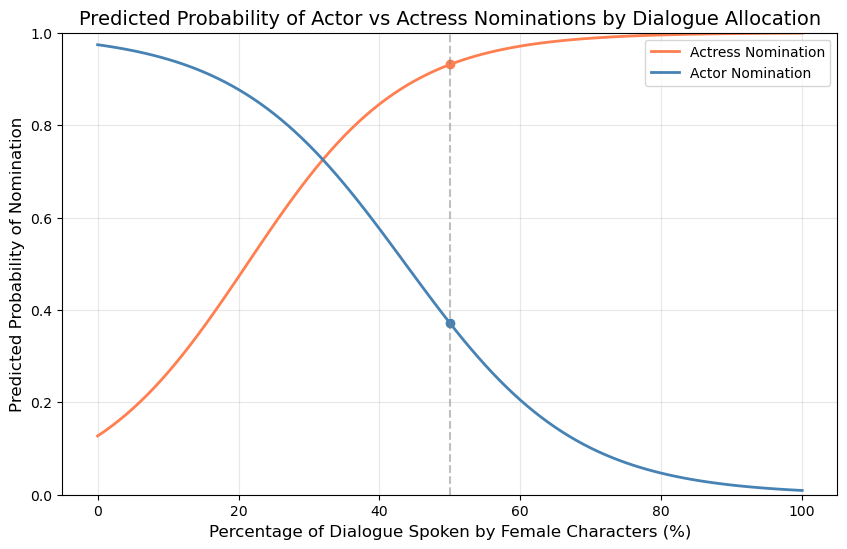

In [13]:

# Coefficients from your logistic regression models
# Actress nominations
intercept_actress = 1.7367
coef_f_actress = 5.3997
coef_m_actress = -3.6630

# Actor nominations
intercept_actor = -0.3505
coef_f_actor = -4.3258
coef_m_actor = 3.9753

# Generate pct_words_f from 0 to 1
pct_words_f = np.linspace(0, 1, 101)
pct_words_m = 1 - pct_words_f  # Because they sum to 1

# Compute logit for actress
logit_actress = intercept_actress + coef_f_actress*pct_words_f + coef_m_actress*pct_words_m
prob_actress = 1 / (1 + np.exp(-logit_actress))

# Compute logit for actor
logit_actor = intercept_actor + coef_f_actor*pct_words_f + coef_m_actor*pct_words_m
prob_actor = 1 / (1 + np.exp(-logit_actor))

# Plot
plt.figure(figsize=(10,6))
plt.plot(pct_words_f*100, prob_actress, label='Actress Nomination', color='coral', linewidth=2)
plt.plot(pct_words_f*100, prob_actor, label='Actor Nomination', color='steelblue', linewidth=2)
plt.axvline(50, color='gray', linestyle='--', alpha=0.5)
plt.scatter(50, 0.932, color='coral')  # 50% female dialogue actress probability
plt.scatter(50, 0.371, color='steelblue')  # 50% female dialogue actor probability

plt.xlabel('Percentage of Dialogue Spoken by Female Characters (%)', fontsize=12)
plt.ylabel('Predicted Probability of Nomination', fontsize=12)
plt.title('Predicted Probability of Actor vs Actress Nominations by Dialogue Allocation', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1)
plt.show()
